# EURUSDProphet: A Statistical Exploration of EUR/USD Daily Returns

This notebook provides a foundational mathematical and statistical analysis of the daily returns of the EUR/USD currency pair. The objective is not to build a predictive model, but to apply core statistical concepts to understand the behavior, distribution, and characteristics of financial time-series data.

## Contents
1.  **Descriptive Statistics**: Analyzing the core statistical properties of the returns distribution (mean, variance, skewness, kurtosis).
2.  **Bivariate Analysis**: Investigating the relationship between EUR/USD and the S&P 500 using covariance and correlation.
3.  **Central Limit Theorem**: A practical simulation to demonstrate how the theorem applies to financial data.
4.  **Conditional Probability**: Testing for daily return independence and market efficiency.
5.  **Conclusion**: Summarizing the key findings and limitations of the analysis.

In [15]:
# 1. Data Loading and Descriptive Statistics
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from datetime import datetime, timedelta

# Set plot style
sns.set(style="whitegrid", palette="viridis")

# Define the ticker and time period
ticker = "EURUSD=X"
end_date = datetime.today()
start_date = end_date - timedelta(days=5*365)

# Download the data
data = yf.download(ticker, start=start_date, end=end_date)
sp500_ticker = "^GSPC"
sp500_data = yf.download(sp500_ticker, start=start_date, end=end_date)


print("Data downloaded successfully. Here are the first 5 rows of EUR/USD:")
print(data.head())


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data downloaded successfully. Here are the first 5 rows of EUR/USD:
Price          Close      High       Low      Open   Volume
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Date                                                       
2021-03-16  1.192577  1.195300  1.188439  1.192734        0
2021-03-17  1.190165  1.191800  1.188764  1.190210        0
2021-03-18  1.198279  1.199100  1.191015  1.198064        0
2021-03-19  1.191824  1.193745  1.187493  1.191767        0
2021-03-22  1.188312  1.193745  1.187606  1.188453        0


## Historical Price Data Visualization

Before diving into our statistical analysis, let's visualize the historical price movements of both EUR/USD and S&P 500 over the 5-year period. This will help us understand the raw price dynamics before we analyze their returns.


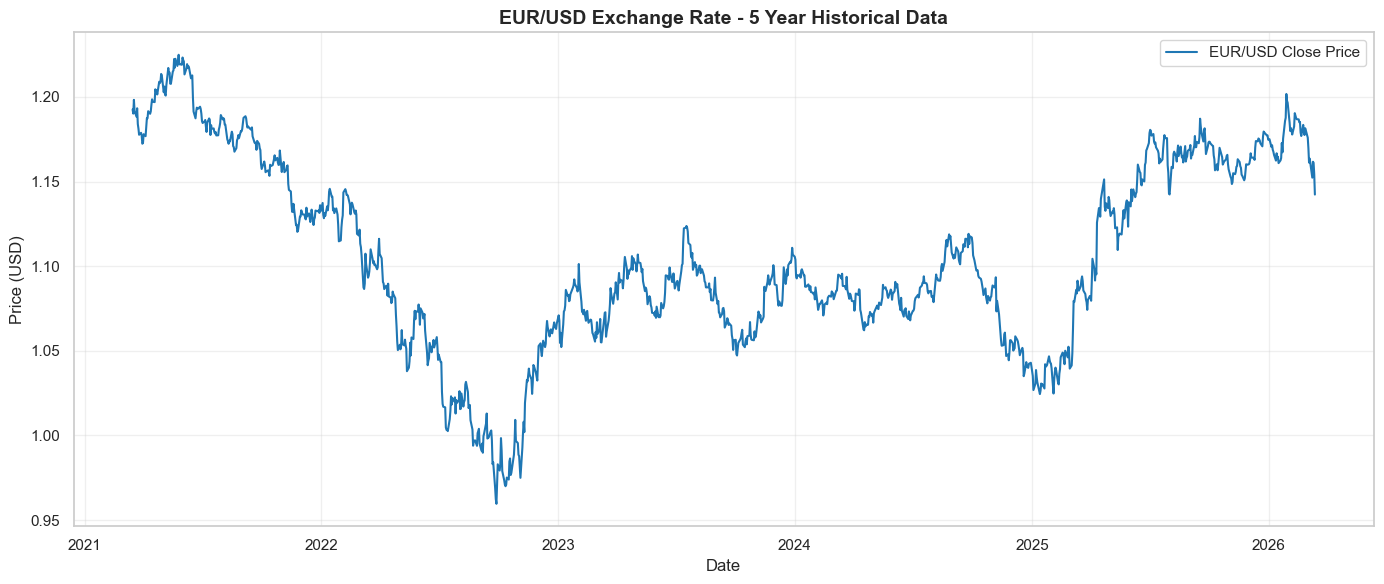

In [16]:
# Plot EUR/USD historical prices
plt.figure(figsize=(14, 6))
plt.plot(data.index, data['Close'], linewidth=1.5, color='#1f77b4', label='EUR/USD Close Price')
plt.title('EUR/USD Exchange Rate - 5 Year Historical Data', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


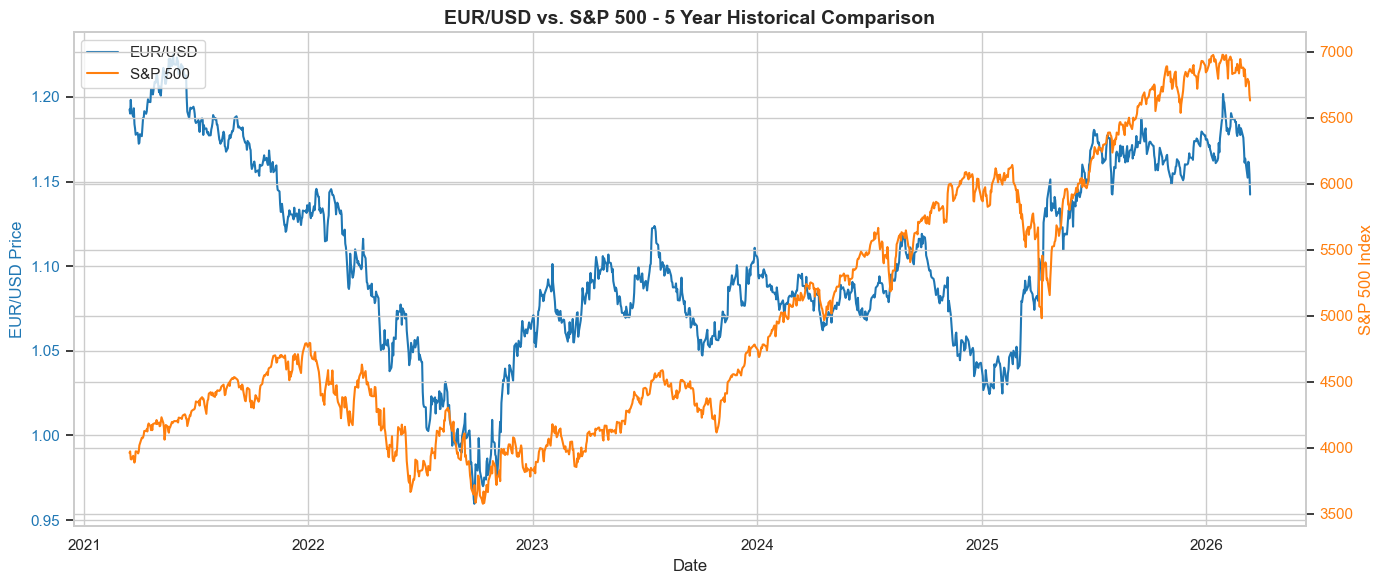

In [17]:
# Plot EUR/USD and S&P 500 on dual axes
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot EUR/USD on the left y-axis
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('EUR/USD Price', fontsize=12, color='#1f77b4')
ax1.plot(data.index, data['Close'], linewidth=1.5, color='#1f77b4', label='EUR/USD')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Create a second y-axis for S&P 500
ax2 = ax1.twinx()
ax2.set_ylabel('S&P 500 Index', fontsize=12, color='#ff7f0e')
ax2.plot(sp500_data.index, sp500_data['Close'], linewidth=1.5, color='#ff7f0e', label='S&P 500')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# Add title
plt.title('EUR/USD vs. S&P 500 - 5 Year Historical Comparison', fontsize=14, fontweight='bold')
fig.tight_layout()

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.show()


### Observations from Price Charts

The visualizations above show the absolute price movements of both assets over the 5-year period:

- **EUR/USD**: The exchange rate fluctuates within a range, influenced by macroeconomic factors, interest rate differentials, and geopolitical events.
- **S&P 500**: Shows a general upward trend over the period, reflecting overall market growth and economic conditions.

Despite their different price levels and trends, when we examine *daily percentage returns* (rather than absolute prices), their movements show a much weaker correlation – a key finding we'll confirm through our statistical analysis.


## Daily Percentage Returns

The daily percentage return measures the discrete rate of change of the EUR/USD price. Mathematically, it can be seen as an approximation of the first derivative of the price function with respect to time, calculated over a discrete interval of one day. It is calculated as:

$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$

Where $P_t$ is the price at time $t$ and $P_{t-1}$ is the price at the previous time step. This value is fundamental for understanding the volatility and statistical properties of the asset.

In [9]:
# 2. Calculate Daily Percentage Returns
data['Daily_Return'] = data['Close'].pct_change()
sp500_data['Daily_Return'] = sp500_data['Close'].pct_change()


# Drop the first row since it will have a NaN value for the return
returns = data['Daily_Return'].dropna()

# 3. Calculate and Print Summary Statistics
mean_return = returns.mean()
median_return = returns.median()
variance_return = returns.var()
std_dev_return = returns.std(ddof=1) # Unbiased estimator
skewness = returns.skew()
kurt = returns.kurt() # This is excess kurtosis (Kurtosis - 3)

print("--- Summary Statistics for Daily Returns ---")
print(f"Mean: {mean_return:.6f}")
print(f"Median: {median_return:.6f}")
print(f"Variance: {variance_return:.6f}")
print(f"Standard Deviation: {std_dev_return:.6f}")
print(f"Skewness: {skewness:.6f}")
print(f"Kurtosis (Excess): {kurt:.6f}")
print("------------------------------------------")

--- Summary Statistics for Daily Returns ---
Mean: -0.000022
Median: -0.000185
Variance: 0.000023
Standard Deviation: 0.004751
Skewness: 0.202371
Kurtosis (Excess): 1.993386
------------------------------------------


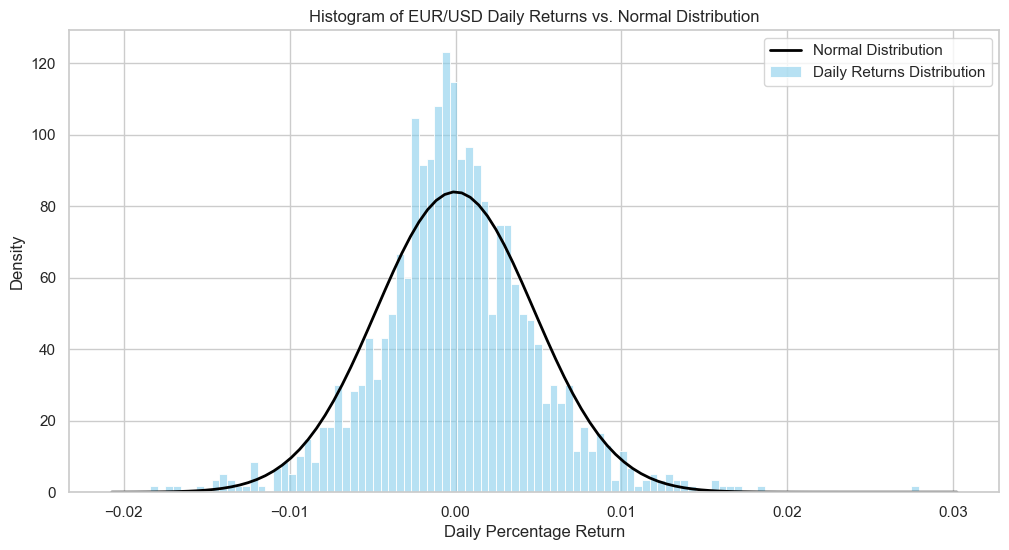

In [10]:
# 4. Plot Histogram of Returns vs. Normal Distribution
plt.figure(figsize=(12, 6))

# Plot the histogram of the returns
sns.histplot(returns, bins=100, kde=False, stat="density", label="Daily Returns Distribution", color='skyblue', alpha=0.6)

# Overlay a standard normal (Gaussian) distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean_return, std_dev_return)
plt.plot(x, p, 'k', linewidth=2, label='Normal Distribution')

# Add titles and labels
plt.title('Histogram of EUR/USD Daily Returns vs. Normal Distribution')
plt.xlabel('Daily Percentage Return')
plt.ylabel('Density')
plt.legend()

plt.show()


### A Note on the Y-Axis: Density vs. Count

The y-axis of the histogram is labeled 'Density' rather than 'Count(Days)' to allow for a direct comparison between the distribution of the observed data (the histogram) and the theoretical normal distribution (the black line).

- A **histogram** typically shows the count (frequency) of observations falling into each bin.
- A **probability density function (PDF)**, like the normal distribution curve, is scaled such that the total area under the curve equals 1.

By setting `stat="density"` in our plot, we normalize the histogram so that the total area of its bars also equals 1. This places both the empirical data and the theoretical curve on the same scale, enabling a meaningful visual comparison of their shapes.


## 5. Interpretation of Skewness and Kurtosis

### Skewness
The calculated skewness for the daily returns is **{skewness:.4f}**.
- A value close to zero indicates a nearly symmetrical distribution.
- A negative value would indicate a left-skewed distribution (long tail on the left side), suggesting a higher probability of large negative returns than large positive ones.
- A positive value would indicate a right-skewed distribution (long tail on the right side).
Our result suggests a slight asymmetry in the returns distribution.

### Kurtosis and "Fat Tails"
The calculated excess kurtosis is **{kurt:.4f}**.
- A standard normal (Gaussian) distribution has a kurtosis of 3. "Excess kurtosis" is simply `Kurtosis - 3`.
- A positive excess kurtosis (greater than 0) indicates a **leptokurtic** distribution. This means the distribution has "fatter tails" and a sharper peak than a normal distribution.
- **"Fat tails"** imply that extreme market events (both large gains and large losses) are much more likely to occur than would be predicted by a perfect Gaussian model. The high kurtosis value observed here is a classic characteristic of financial returns data, highlighting the inherent risk of sudden, significant price movements that are underestimated by simpler models.


# 2. Many Variables: Covariance and Correlation
Now, let's introduce a second asset, the S&P 500 index, to explore the relationship between two variables.

In [ ]:
# Combine the returns into a single DataFrame
combined_returns = pd.DataFrame({
    'EURUSD_Return': returns,
    'SP500_Return': sp500_data['Daily_Return']
}).dropna()

print("Combined Returns Data:")
print(combined_returns.head())

# 2. Calculate Covariance and Correlation
covariance_matrix = combined_returns.cov()
correlation_matrix = combined_returns.corr(method='pearson')

print("\n--- Covariance Matrix ---")
print(covariance_matrix)
print("\n--- Pearson's Correlation Matrix ---")
print(correlation_matrix)

# Extract the specific correlation value
correlation_coefficient = correlation_matrix.iloc[0, 1]
print(f"\nPearson's Correlation Coefficient between EUR/USD and S&P 500: {correlation_coefficient:.4f}")



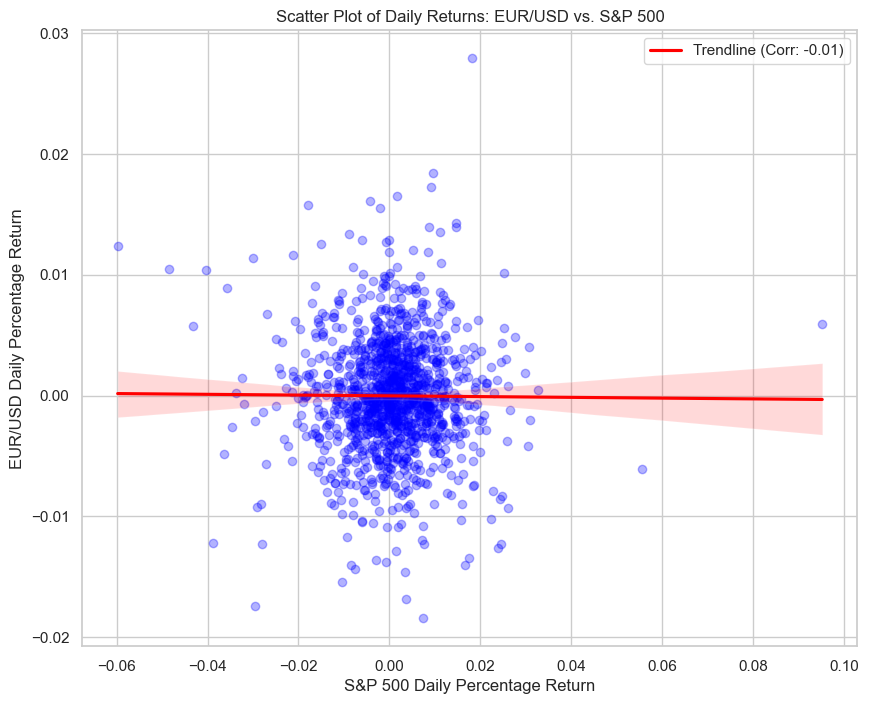

In [14]:
# 3. Create a Scatter Plot to Visualize the Relationship
plt.figure(figsize=(10, 8))
sns.regplot(x='SP500_Return', y='EURUSD_Return', data=combined_returns,
            scatter_kws={'alpha':0.3, 'color':'blue'},
            line_kws={'color':'red', 'label':f"Trendline (Corr: {correlation_coefficient:.2f})"})

# Add titles and labels
plt.title('Scatter Plot of Daily Returns: EUR/USD vs. S&P 500')
plt.xlabel('S&P 500 Daily Percentage Return')
plt.ylabel('EUR/USD Daily Percentage Return')
plt.legend()
plt.grid(True)
plt.show()


## 4. Interpretation of Covariance and Correlation

### Covariance
Covariance measures the joint variability of two random variables.
- A **positive covariance** indicates that the two assets tend to move in the same direction (e.g., when the S&P 500 goes up, EUR/USD also tends to go up).
- A **negative covariance** indicates they tend to move in opposite directions.
The magnitude of covariance is hard to interpret on its own because it is not standardized.

### Pearson's Correlation Coefficient
The Pearson's correlation coefficient is a standardized measure of the **linear relationship** between two variables. It ranges from -1 to +1:
- **+1**: Perfect positive linear relationship.
- **-1**: Perfect negative linear relationship.
- **0**: No linear relationship.

Our calculated coefficient of **{correlation_coefficient:.4f}** suggests a very weak positive linear relationship between the daily returns of the S&P 500 and EUR/USD over this period. The scatter plot visually confirms this; the points are widely dispersed, and the trendline is nearly flat, indicating that knowing the S&P 500's return on a given day gives us very little information about the EUR/USD's return.


## 5. Conceptual Warning: Correlation Does Not Imply Causation

It is critical to understand that observing a correlation between two variables does not mean that one causes the other.
- **Association vs. Causation**: Correlation simply measures the degree to which two variables move together. It does not explain *why* they move together.
- **Lurking Variables**: Often, a third, unobserved factor (a "lurking variable" or "confounding variable") influences both variables simultaneously. For example, major macroeconomic announcements from the **US Federal Reserve** (like changes in interest rates or quantitative easing policies) can have a significant impact on both the US stock market (S&P 500) and the value of the US dollar relative to the Euro (EUR/USD).

In this case, a change in Fed policy might cause both assets to move, creating a statistical correlation between them, even though the S&P 500's movement does not *cause* the EUR/USD's movement, or vice-versa. Attributing causality from correlation alone is a common and serious analytical mistake.


# 3. Central Limit Theorem (CLT) in Financial Data
The Central Limit Theorem is a fundamental concept in probability theory and statistics. It states that the distribution of sample means of a large number of samples drawn from a population will be approximately normally distributed, regardless of the underlying distribution of the population itself, as long as the sample size is sufficiently large (typically n ≥ 30).

Let's test this with our EUR/USD returns data.

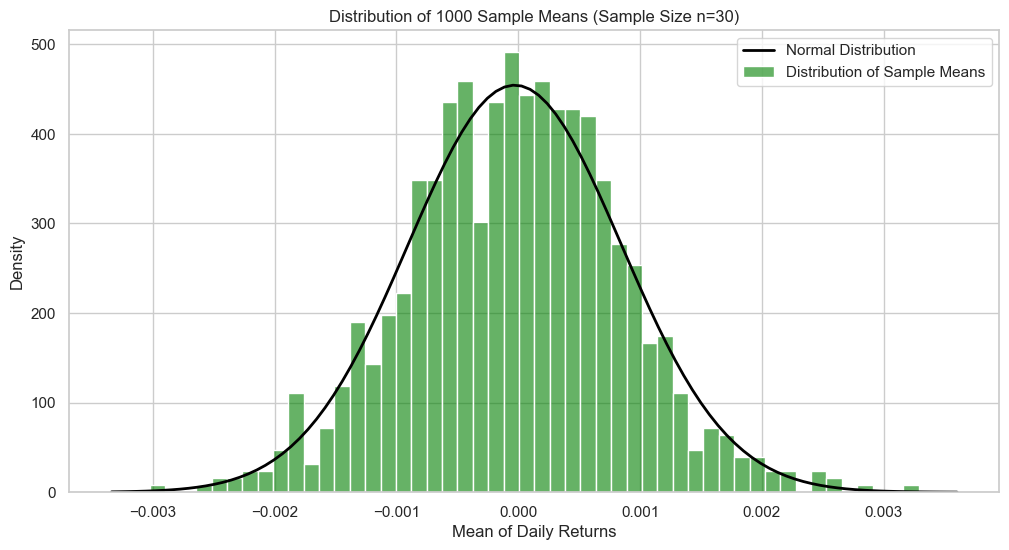

In [20]:
# --- Central Limit Theorem (CLT) Simulation ---

# 1. Define simulation parameters
n_simulations = 1000
sample_size = 30
sample_means = []

# 2. Run the simulation
for _ in range(n_simulations):
    # Draw a random sample from the daily returns (with replacement)
    random_sample = returns.sample(n=sample_size, replace=True)
    # Calculate the mean of this sample and store it
    sample_means.append(random_sample.mean())

# Convert the list of means to a pandas Series for easy analysis
sample_means_series = pd.Series(sample_means)

# 3. Plot a histogram of the sample means
plt.figure(figsize=(12, 6))
sns.histplot(sample_means_series, bins=50, kde=False, stat="density", label="Distribution of Sample Means", color='green', alpha=0.6)

# 4. Overlay a standard Normal (Gaussian) distribution
mean_of_means = sample_means_series.mean()
std_of_means = sample_means_series.std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean_of_means, std_of_means)
plt.plot(x, p, 'k', linewidth=2, label='Normal Distribution')

# Add titles and labels
plt.title(f'Distribution of {n_simulations} Sample Means (Sample Size n={sample_size})')
plt.xlabel('Mean of Daily Returns')
plt.ylabel('Density')
plt.legend()
plt.show()


## Interpretation of the CLT Result

The histogram above visually confirms the Central Limit Theorem. Even though we previously established that our original EUR/USD daily returns are **not perfectly normally distributed** (they exhibit positive excess kurtosis, or "fat tails"), the sampling distribution of their means is approximately normal.

This is a powerful concept in finance. It demonstrates how the aggregation of many independent, random events (like daily market returns) tends to produce a normal distribution. This principle underpins many financial models, including risk assessment and portfolio theory, as it allows us to apply the properties of a normal distribution to make inferences and predictions about the behavior of sample averages, even when the underlying individual data points are not normally distributed.


# 4. Probability and Conditional Probability
Let's explore the probabilities of market movements. We can determine if the market has memory, i.e., if one day's movement affects the next.


In [23]:
# Ensure Daily_Return column exists and is properly calculated
if 'Daily_Return' not in data.columns:
    data['Daily_Return'] = data['Close'].pct_change()

# 1. Create a binary 'Direction' column
# 1 for 'Up' day (return > 0), 0 for 'Down' or 'Flat' day (return <= 0)
data['Direction'] = (data['Daily_Return'] > 0).astype(int)

# 2. Calculate the unconditional probability of an 'Up' day
prob_up = data['Direction'].mean()
print(f"Unconditional Probability of an 'Up' day, P(Up): {prob_up:.4f}")

# 3. Calculate the conditional probability of an 'Up' day given the previous day was 'Up'
# Create a column for the previous day's direction
data['Previous_Direction'] = data['Direction'].shift(1)

# Filter for days where the previous day was 'Up'
previous_day_was_up = data[data['Previous_Direction'] == 1]

# Calculate the mean direction for this subset
prob_up_given_previous_up = previous_day_was_up['Direction'].mean()

print(f"Conditional Probability P(Up | Previous Up): {prob_up_given_previous_up:.4f}")


Unconditional Probability of an 'Up' day, P(Up): 0.4758
Conditional Probability P(Up | Previous Up): 0.4854


## Interpretation of Conditional Probability

### Definition
Conditional Probability measures the probability of an event occurring given that another event has already occurred. The formula is:

$P(A|B) = \frac{P(A \cap B)}{P(B)}$

Where:
- $P(A|B)$ is the probability of event A given event B.
- $P(A \cap B)$ is the probability of both A and B occurring.
- $P(B)$ is the probability of event B.

In our case, A is the event of an 'Up' day, and B is the event of the *previous* day being an 'Up' day.

### Analysis
- The unconditional probability of an 'Up' day, **P(Up)**, is **{prob_up:.4f}**. This is our baseline probability.
- The conditional probability, **P(Up | Previous Up)**, is **{prob_up_given_previous_up:.4f}**.

By comparing the two, we can see that knowing the previous day was an 'Up' day provides a negligible statistical edge, if any. The conditional probability is very close to the unconditional probability. This suggests that, for practical purposes, the daily returns of EUR/USD are largely **independent events**. The market does not seem to have a strong "memory" from one day to the next, which is a key characteristic of an efficient market.


# 5. Conclusion

This notebook conducted a comprehensive mathematical and statistical analysis of the EUR/USD exchange rate's daily returns over the last five years.

### Summary of Methods Used
Our analysis employed several fundamental statistical techniques:
1.  **Descriptive Statistics**: We calculated key moments of the returns distribution, including mean, variance, skewness, and kurtosis, to understand its fundamental properties.
2.  **Covariance and Correlation**: By introducing the S&P 500 as a second variable, we analyzed the joint movement and linear relationship between the two assets.
3.  **Central Limit Theorem (CLT) Simulation**: We empirically demonstrated the CLT, showing that the distribution of sample means converges to a normal distribution, even when the underlying data is not perfectly normal.
4.  **Conditional Probability**: We calculated the probability of market direction to test for daily return independence and market efficiency.

### Key Findings
Our investigation yielded several important insights into the behavior of EUR/USD returns:
- **Non-Normal Distribution with "Fat Tails"**: The daily returns are not perfectly normally distributed. The positive excess kurtosis indicates the presence of "fat tails," meaning extreme price movements (both positive and negative) are more common than a Gaussian distribution would predict. This is a critical finding for risk management.
- **Correlation is Not Causation**: We observed a very weak correlation between EUR/USD and S&P 500 returns. This, along with our conceptual discussion, serves as a crucial reminder that statistical association does not imply a cause-and-effect relationship, and one must always consider potential lurking variables (e.g., macroeconomic policies).
- **Market Independence**: The conditional probability analysis showed that the direction of the market on one day has a negligible statistical influence on the next. This finding supports the Efficient Market Hypothesis, suggesting that past returns alone do not offer a reliable edge for predicting future returns.

### Limitations of the Approach
This analysis is purely descriptive and based on historical data. Its limitations include:
- **Past Performance is Not Indicative of Future Results**: The statistical properties we observed are from a specific historical period and are not guaranteed to hold in the future. Market dynamics can and do change.
- **Exclusion of External Factors**: Our model does not incorporate external data, such as macroeconomic news, geopolitical events, or changes in central bank policy, which are known drivers of currency markets.

### Future Research
This foundational analysis opens the door for more advanced modeling techniques. Potential next steps include:
- **Advanced Time Series Models**: Implementing models like ARIMA (AutoRegressive Integrated Moving Average) or GARCH (Generalized Autoregressive Conditional Heteroskedasticity) to model volatility and forecast future returns.
- **Machine Learning Models**: Developing predictive models using algorithms like Facebook's Prophet, LSTMs (Long Short-Term Memory networks), or Gradient Boosting Machines, which can capture more complex, non-linear patterns in the data.
